# Submission Akhir BMLP - Clustering

**Nama:** Muhammad Azri Fatih Susanto

Notebook ini melakukan clustering (unsupervised learning) pada dataset `dataset_clustering_project` (modifikasi dari *Bank Transaction Dataset for Fraud Detection*) untuk menghasilkan label/kelas yang selanjutnya dipakai pada notebook klasifikasi.

## 1. Import Library

In [1]:
# Import library
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Memuat Dataset

In [2]:
# Load data
# Sesuaikan nama file dengan dataset yang sudah Anda unduh dari Google Drive
# dan letakkan di dalam folder data/
df = pd.read_csv("data/bank_transactions_data_edited.csv")

## 3. Exploratory Data Analysis

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe(include="all")

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX000592,AC00363,NaN,2023-10-20 17:53:13,Debit,Fort Worth,D000315,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


### Korelasi dan Distribusi Fitur

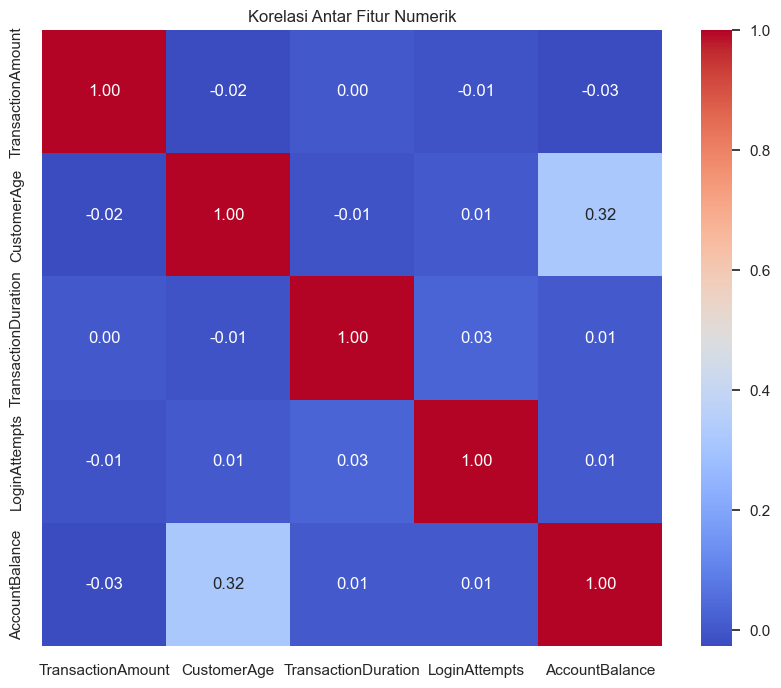

In [6]:
# Menampilkan korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

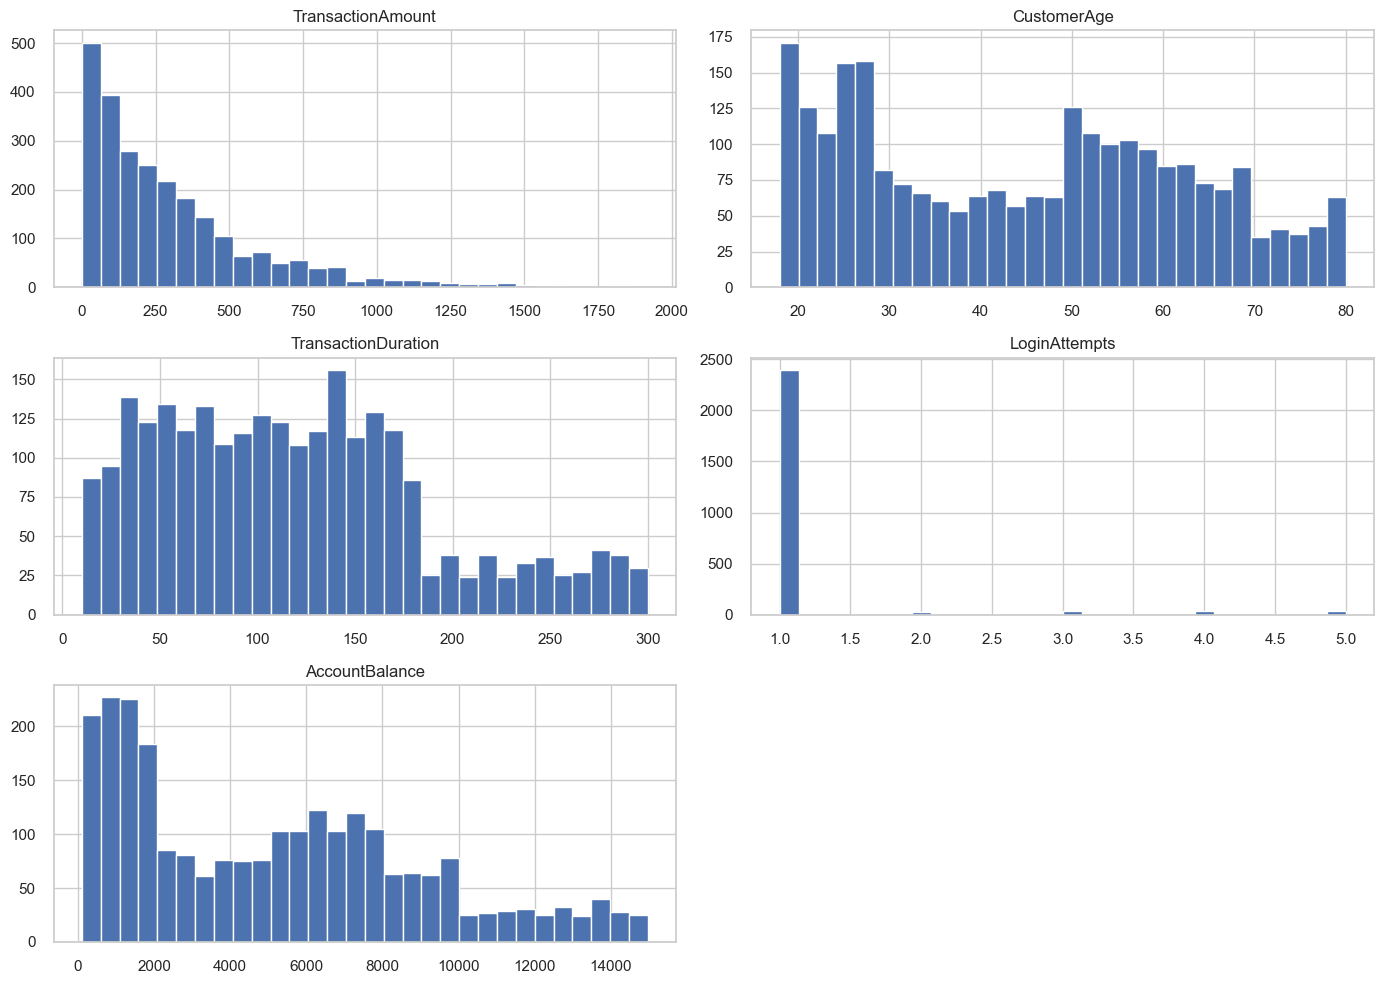

In [7]:
# Menampilkan histogram untuk semua kolom numerik
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

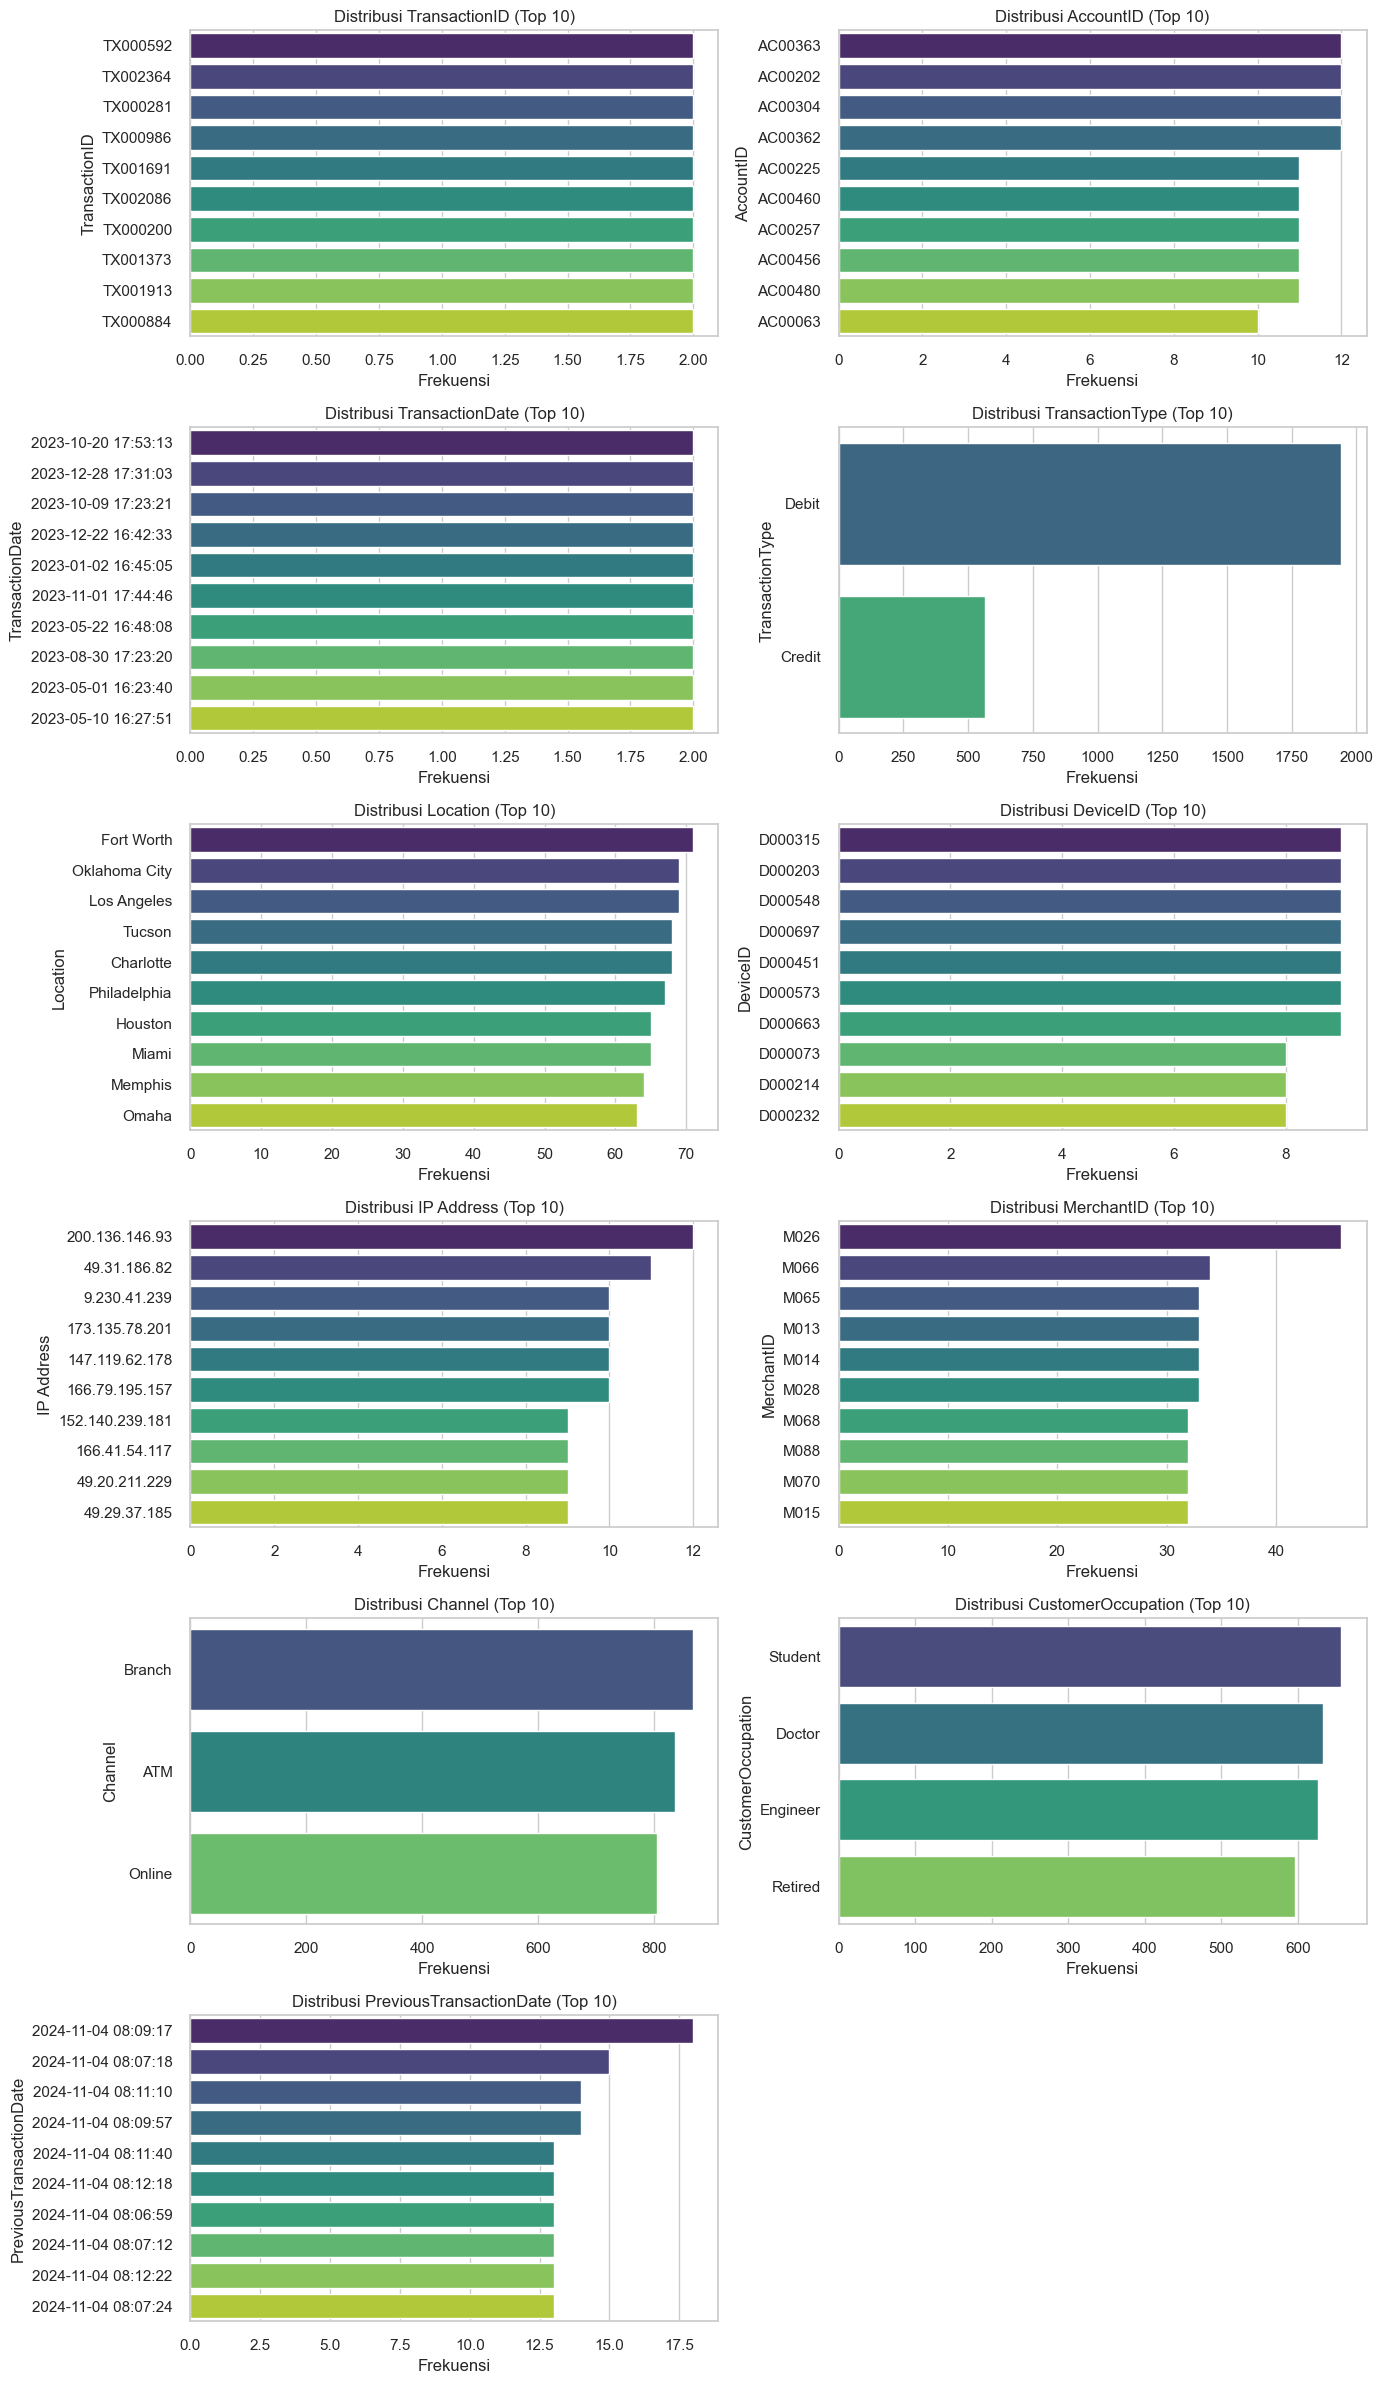

In [8]:
# Menampilkan histogram (bar chart frekuensi) untuk semua kolom kategorikal
cat_cols_eda = df.select_dtypes(include="object").columns
n_cols = 2
n_rows = int(np.ceil(len(cat_cols_eda) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cat_cols_eda):
    top_categories = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax, hue=top_categories.index, palette="viridis", legend=False)
    ax.set_title(f"Distribusi {col} (Top 10)")
    ax.set_xlabel("Frekuensi")
    ax.set_ylabel(col)

for ax in axes[len(cat_cols_eda):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

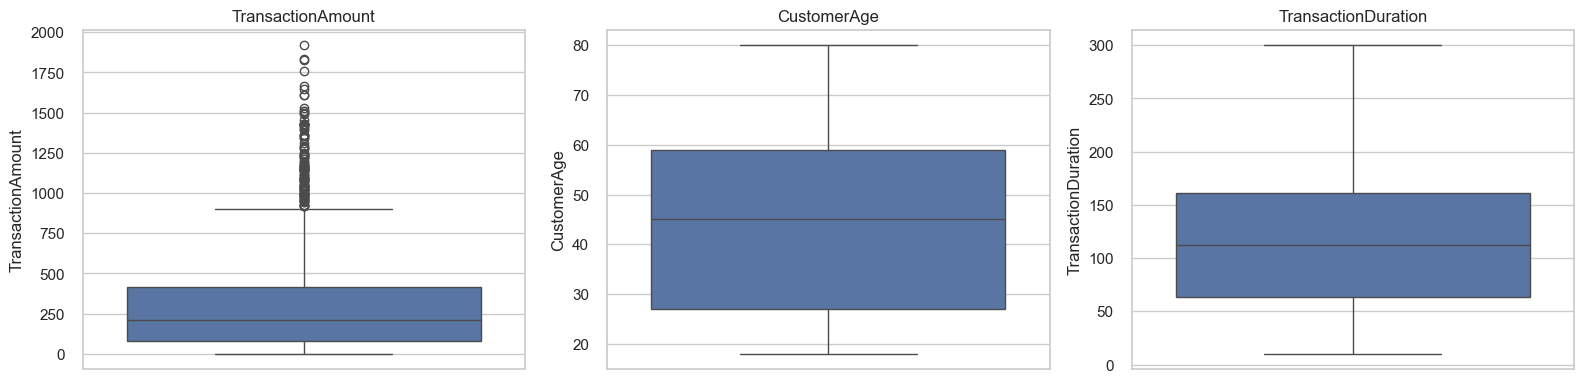

In [9]:
# Visualisasi yang lebih informatif 
num_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(1, min(3, len(num_cols)), figsize=(16, 4))
for ax, col in zip(np.atleast_1d(axes), num_cols[:3]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

In [11]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [12]:
# Menangani data yang hilang.
df = df.dropna()

In [13]:
# Menghapus data duplikat.
df = df.drop_duplicates()

In [14]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address
cols_to_drop = [col for col in df.columns
                if ("date" in col.lower()) or ("id" in col.lower()) or ("ip" in col.lower())]
df = df.drop(columns=cols_to_drop)
cols_to_drop

['TransactionID',
 'AccountID',
 'TransactionDate',
 'DeviceID',
 'IP Address',
 'MerchantID',
 'PreviousTransactionDate']

In [15]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
cat_cols = df.select_dtypes(include="object").columns
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [16]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [17]:
# Melakukan Handling Outlier Data menggunakan metode drop.
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in cat_cols]

# LoginAttempts didominasi nilai 1 (lihat describe di atas), sehingga setelah
# outlier removal variansinya menjadi 0 dan menyebabkan StandardScaler membagi
# dengan 0 (menghasilkan NaN/Inf). Kolom ini dikeluarkan dari fitur numerik
# yang dipakai untuk outlier handling, scaling, dan clustering.
num_cols = [c for c in num_cols if c != "LoginAttempts"]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask].reset_index(drop=True)

In [18]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

In [19]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# Sesuaikan nama kolom dengan fitur numerik yang relevan pada dataset Anda
binning_col = num_cols[0]
bin_col_name = f"{binning_col}_bin"
df[bin_col_name] = pd.qcut(df[binning_col], q=4,
                            labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"])

# Encode hasil binning menggunakan LabelEncoder, dan daftarkan encoder-nya
# supaya nilai kategori aslinya bisa dikembalikan lagi lewat inverse_transform().
bin_encoder = LabelEncoder()
df[bin_col_name] = bin_encoder.fit_transform(df[bin_col_name].astype(str))
encoders[bin_col_name] = bin_encoder

In [20]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
df_scaled.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,2.042000e+03,2042.000000,2042.000000,2042.000000,2.042000e+03,2042.000000,2.042000e+03,2042.000000,2.042000e+03
mean,1.948599e-16,0.771792,21.233595,0.976494,1.330963e-16,1.497551,1.739821e-17,1.118511,2.435749e-16
std,1.000245e+00,0.419780,12.299297,0.805685,1.000245e+00,1.135263,1.000245e+00,0.580307,1.000245e+00
min,-1.178346e+00,0.000000,0.000000,0.000000,-1.501505e+00,0.000000,-1.552181e+00,1.000000,-1.281148e+00
25%,-8.160816e-01,1.000000,11.000000,0.000000,-9.953483e-01,0.000000,-8.037557e-01,1.000000,-9.271318e-01
50%,-2.629686e-01,1.000000,21.000000,1.000000,1.696554e-02,1.000000,-1.047544e-01,1.000000,-1.070491e-01
75%,5.394212e-01,1.000000,32.000000,2.000000,8.043208e-01,3.000000,5.942469e-01,1.000000,6.593596e-01
max,2.967528e+00,1.000000,42.000000,2.000000,1.985354e+00,3.000000,2.542978e+00,5.000000,2.509992e+00


## 5. Pembangunan Model Clustering

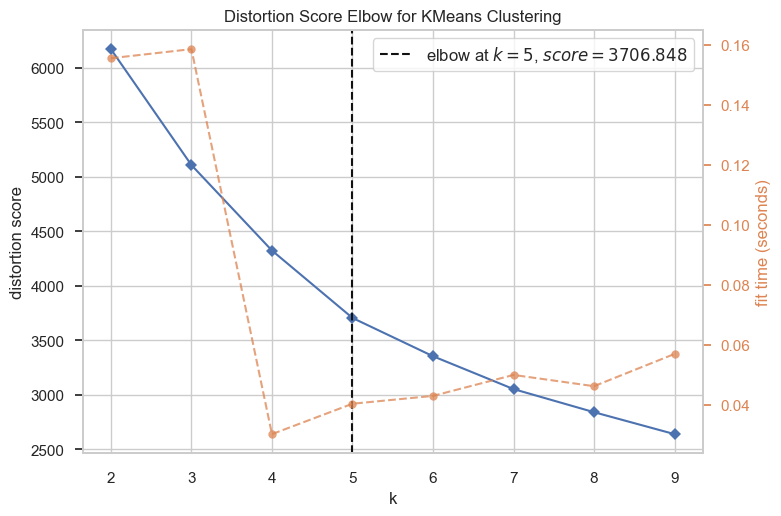

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
X = df_scaled[num_cols]
visualizer = KElbowVisualizer(KMeans(random_state=42, n_init=10), k=(2, 10))
visualizer.fit(X)
visualizer.show()

In [22]:
# Menggunakan algoritma K-Means Clustering
n_clusters = visualizer.elbow_value_ or 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

In [23]:
# Menyimpan model menggunakan joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

In [24]:
# Menghitung dan menampilkan nilai Silhouette Score.
score = silhouette_score(X, cluster_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2524


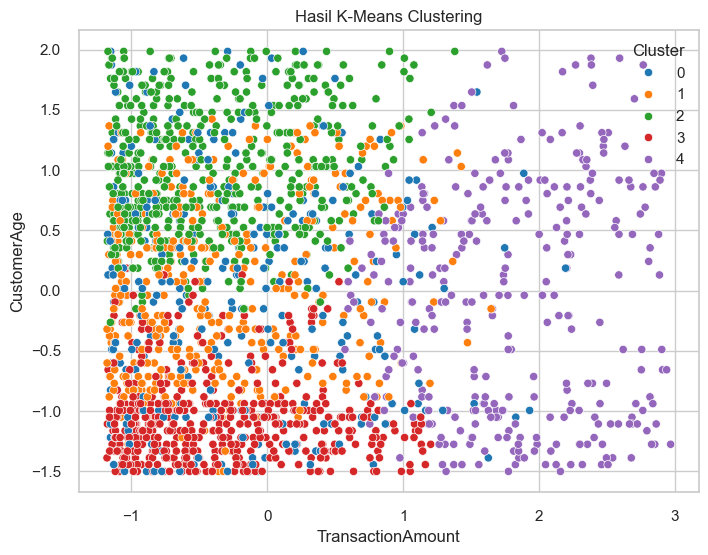

In [25]:
# Membuat visualisasi hasil clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=cluster_labels, palette="tab10")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Hasil K-Means Clustering")
plt.legend(title="Cluster")
plt.show()

### Membangun Model PCA sebagai Pembanding

In [26]:
# Membangun model menggunakan PCA.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.33422384 0.25067197]


In [27]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini
joblib.dump(pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

## 6. Interpretasi Model / Analisis Setiap Cluster

**Metode yang digunakan:** analisis deskriptif (mean, min, max) per cluster pada fitur numerik, dilengkapi modus untuk fitur kategorikal hasil inverse transform.

**Alasan penggunaan:** untuk memahami karakteristik tiap cluster secara kuantitatif sebelum diberi label bermakna.

**Hasil yang didapat:**

- **Cluster 0 - Transaksi berdurasi lama:** rata-rata durasi transaksi jauh lebih panjang dibanding cluster lain (±241 detik, rentang 152-300 detik), dengan nominal transaksi menengah (rata-rata ±215) dan saldo rekening menengah (±5,3 juta). Didominasi kanal Branch dan profesi Engineer.
- **Cluster 1 - Nasabah bersaldo tinggi:** saldo rekening rata-rata paling besar di antara semua cluster (±10,4 juta), namun nominal transaksi per transaksi relatif standar (±183). Didominasi kanal Branch dan profesi Doctor.
- **Cluster 2 - Nasabah lanjut usia, transaksi kecil:** usia rata-rata paling tua (±62 tahun) dan durasi transaksi tercepat (±93 detik) dengan nominal transaksi terkecil (±171). Didominasi kanal ATM dan profesi Retired - konsisten dengan pola nasabah pensiunan yang bertransaksi sederhana lewat ATM.
- **Cluster 3 - Nasabah muda, saldo rendah:** usia rata-rata paling muda (±26 tahun) dan saldo rekening paling rendah (±1,6 juta) di antara semua cluster. Didominasi kanal Branch dan profesi Student.
- **Cluster 4 - Transaksi bernilai tinggi:** nominal transaksi jauh di atas cluster lain (rata-rata ±649, dengan nilai minimum 381 saja sudah melebihi nilai maksimum di keempat cluster lainnya), sehingga cluster ini terpisah cukup jelas sebagai segmen transaksi besar. Didominasi kanal ATM dan profesi Engineer.

Secara umum, kelima cluster terbentuk terutama berdasarkan kombinasi nominal transaksi, durasi transaksi, usia, dan saldo rekening - bukan berdasarkan lokasi atau jenis transaksi (karena hampir seluruh cluster didominasi `TransactionType = Debit`).

In [28]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
df["Target"] = cluster_labels
df.groupby("Target")[num_cols].agg(["mean", "min", "max"])

TransactionAmount                 CustomerAge              \
                    mean     min     max        mean   min   max   
Target                                                             
0             214.628339    1.41  734.86   44.982699  18.0  80.0   
1             183.340175    0.32  615.58   45.433915  18.0  70.0   
2             171.497030    0.84  557.41   62.492481  40.0  80.0   
3             182.208904    0.26  518.85   25.922311  18.0  48.0   
4             648.808302  381.52  903.19   43.383648  18.0  80.0   

       TransactionDuration               AccountBalance                     
                      mean    min    max           mean      min       max  
Target                                                                      
0               241.463668  152.0  300.0    5327.900104   135.96  14348.65  
1                99.620948   10.0  225.0   10361.665711  5677.52  14977.99  
2                93.492481   10.0  213.0    4579.820695   120.89   9073.17  
3                99.149402   10.0  220.0    1593.685040   105.01   7047.04  
4               112.047170   10.0  288.0    4850.806038   102.20  14935.50

In [29]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'TransactionAmount_bin',
 'Target']

In [30]:
# Simpan Data
df.to_csv("data_clustering.csv", index=False)

## 7. Inverse Transform Data

In [31]:
# inverse dataset ke rentang normal untuk numerikal
df_inverse = df.copy()
df_inverse[num_cols] = scaler.inverse_transform(df_scaled[num_cols])

In [32]:
# inverse dataset yang sudah diencode ke kategori aslinya.
for col, le in encoders.items():
    df_inverse[col] = le.inverse_transform(df[col])

In [33]:
# Analisis deskriptif (mean, min, max) untuk fitur numerik dan modus untuk
# fitur kategorikal, menggunakan data yang sudah di-inverse.
display(df_inverse.groupby("Target")[num_cols].agg(["mean", "min", "max"]))
display(df_inverse.groupby("Target")[list(encoders.keys())].agg(lambda x: x.mode().iloc[0]))

TransactionAmount                 CustomerAge              \
                    mean     min     max        mean   min   max   
Target                                                             
0             214.628339    1.41  734.86   44.982699  18.0  80.0   
1             183.340175    0.32  615.58   45.433915  18.0  70.0   
2             171.497030    0.84  557.41   62.492481  40.0  80.0   
3             182.208904    0.26  518.85   25.922311  18.0  48.0   
4             648.808302  381.52  903.19   43.383648  18.0  80.0   

       TransactionDuration               AccountBalance                     
                      mean    min    max           mean      min       max  
Target                                                                      
0               241.463668  152.0  300.0    5327.900104   135.96  14348.65  
1                99.620948   10.0  225.0   10361.665711  5677.52  14977.99  
2                93.492481   10.0  213.0    4579.820695   120.89   9073.17  
3                99.149402   10.0  220.0    1593.685040   105.01   7047.04  
4               112.047170   10.0  288.0    4850.806038   102.20  14935.50

,TransactionType,Location,Channel,CustomerOccupation,TransactionAmount_bin
Target,,,,,
0,Debit,Fresno,Branch,Engineer,Tinggi
1,Debit,Fort Worth,Branch,Doctor,Sedang
2,Debit,Charlotte,ATM,Retired,Rendah
3,Debit,Tucson,Branch,Student,Tinggi
4,Debit,Mesa,ATM,Engineer,Sangat Tinggi


In [34]:
# Periksa kembali data yang telah di-inverse.
df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_bin,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Rendah,2
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Sangat Tinggi,1
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Sedang,3
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Sedang,1
4,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Sedang,3


In [35]:
# Simpan Data Inverse
df_inverse.to_csv("data_clustering_inverse.csv", index=False)